# étoiles binaires spectroscopiques
$\rightarrow$ **analyse de l'étoile12 Boo (données de Philippe)**

## la cible
- 12 Boo est une étoile binaire spectroscopique de la constellation du Bouvier (mV = 4,83)
- La composante primaire (12 Boo Aa) : F8IV
- La composante secondaire (12 Boo Ab) : F8V 
- 12 Boo est une binaire SB2 (double raie) : leur VR/phase montre deux sinusoïdes qui se croisent.
- Quand les étoiles sont "côte à côte" (vu de la Terre), leurs vitesses sont identiques -> un seul pic.
- Quand elles sont à l'opposé sur leur orbite ->  deux pics distincts.

| **Paramètre** | 	Symbole	 | Valeur Pro | 
| -- | --| -- |
| **Période** | $P$ | **9,6045 j** | 9,6045 j (fixé) |
| **Excentricité** | $e$ | **0,192** | **0,178** (Excellent !) |
| **Vitesse systémique** | $\\gamma$ | **\-10,7 km/s** | **\-9,89 km/s** |
| **Amplitude Étoile A** | $K_A$ | **67,2 km/s** | **73,4 km/s** |
| **Amplitude Étoile B** | $K_B$ | **69,3 km/s** | **75,9 km/s** |
| **Argument périastre** | $\\omega$ | **286°** (sec.) | **190°** (primaire) |

--> **pas facile de détecter et de distinguer les deux pics**

## les données 

|||
|---|---|
|OBJECT|	12_Boo  |
|EXPTIME2|	3 x 600 s|
|BSS_ITRP|	16746|
|BSS_VHEL|	0|
|DATE-OBS|	2025-06-16T23:14:30.305 + ...|
|CDELT1| 0.04877652979666891 |                                                 
|BSS_SITE|	Marcenat|
|BSS_INST|	AP115-800 + StarEx2400 + ASI533MM|
|||
             


In [1]:
# import de base
import os, pathlib, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as imageio

import astropy.units as u
from astropy.io import fits
from astropy.nddata import StdDevUncertainty
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time
from astropy.modeling import models
from astropy.stats import mad_std

from specutils import Spectrum
from specutils.fitting import fit_generic_continuum, fit_continuum
from specutils.analysis import centroid, fwhm, snr, snr_derived
from specutils.spectra import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import correlation

from scipy.linalg import svd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.signal import correlate
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter



In [2]:
# 0. Import du dashboard
%matplotlib widget
from spectro_dashboard import SpectroDashboard

# 1. Afficher le dashboard
db = SpectroDashboard()
db.show()


In [56]:
# paramètres connus (pour aider le modèle)

DISP = 0.0487765        # Dispersion StarEx (A/pixel)
LAMBDA_C = 6562.81       # Longueur d'onde centrale (A)
V_PIX = 299792.458 * (DISP / LAMBDA_C) # VR pour un pixel -> 2.22 km/s)
P = 9.591               # Période orbitale de (jours)
T0_REF = 2460844.2      # Date de référence (JD)
K_A = 68.2              # Amplitude étoile A (km/s)
K_B = 70.8              # Amplitude étoile B (km/s)
E_REF = 0.19            # Excentricité de référence
OMEGA_REF = 190         # Argument du périastre (degrés)
GAMMA_REF = -10.5       # Vitesse systémique (km/s)
#OFFSET_INST = 0         # À ajuster selon ta calibration néon
OFFSET_INST = -6.0   # km/s — à affiner après la prochaine itération

# CONFIGURATION & LOCALISATION (Marcenat)
#Latitude : 45,306° N (environ 45° 18' 25'' N)
#Longitude : 2,828° E (environ 2° 49' 36'' E) 

location = EarthLocation(lat=45.306*u.deg, lon=-2.828*u.deg, height=1000*u.m)   
target = SkyCoord.from_name('12 Boo')

# chargement des spectres --> data_list[] et création du GIF animé
files_path = "data/12Boo/_12_boo_202506*.fits"

# plage de recherche et de comparaison avec le template
region_travail = SpectralRegion(6490*u.AA, 6700*u.AA) 
#region_travail = SpectralRegion(6550*u.AA, 6700*u.AA)

# raies générées du spectre synthétique (Fe, Ni, etc...)
synth_lines = [
    #6493.78, 6494.98, 6499.48, #, 6518.37, 6533.93, # Zone bleue
    6456.38, 6481.87, 6493.78, 6494.98, 6499.48,  6518.37, 6517.07, 6546.24,  # Zone bleue
    6562.81,                                     # H alpha
    6633.75, 6643.63, 6663.44, 6678.00, 6696.32  # Zone rouge
]



# chargement des données

In [57]:

files = sorted(glob.glob(files_path))
data_list = []
images = []
temp_file = 'images/temp.png'
gif_file = 'images/12boo_animation.gif'


for f in files:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        spec = Spectrum.read(f)
        
        # Extraction et normalisation 
        spec_sub = extract_region(spec, region_travail)
        #new_flux = (spec_sub.flux.value - np.median(spec_sub.flux.value)) * u.dimensionless_unscaled
        
        #spec_final = Spectrum(flux=new_flux, spectral_axis=spec_sub.spectral_axis)
        spec_final = Spectrum(flux=spec_sub.flux, spectral_axis=spec_sub.spectral_axis)
        jd = float(spec.meta['header']['JD-OBS'])
        data_list.append({'jd': jd, 'spec': spec_final})

        """
        # Création du graphique animé
        plt.figure()
        plt.plot(spec.spectral_axis, spec.flux)
        plt.title(spec.meta['header']['DATE-OBS'])
        plt.ylim(0.3, 1.1)
        plt.xlim(6515, 6700)
        plt.xlabel("Longueur d'onde")
        plt.ylabel("Flux")
        #plt.axvline(x=4861, color='red', linestyle='--', linewidth=1, label='Hbeta')
        plt.legend()
        
        # Sauvegarde temporaire
        plt.savefig(temp_file)
        plt.close()
        
        # Ajout à la liste d'images
        images.append(imageio.imread(temp_file))
        """
        
# Création du GIF
#os.remove(temp_file)
#imageio.imwrite(gif_file, images, duration=500, format='GIF', loop=0)   

#data_list
#[spec['spec'] for spec in data_list]


# génération du 'template'

In [58]:

def generate_synthetic_mask_v0(wavelengths, lines):
    mask = np.ones_like(wavelengths)
        
    for l in lines:
        # On trouve l'index le plus proche et on met 1.0 (un seul pixel)
        #idx = np.abs(wavelengths - l).argmin()
        #mask[idx] = 0.0
        # Ajout des raies (gaussiennes inversées)
        mask -= 0.3 * np.exp(-0.5 * ((wavelengths - l) / 0.1)**2)
        
    return mask

def generate_synthetic_mask(wavelengths, lines):
    mask = np.ones_like(wavelengths)
    sigma_inst = 0.44 / 2.355  # PSF instrumentale à R=15000
    for l in lines:
        mask -= 0.3 * np.exp(-0.5 * ((wavelengths - l) / sigma_inst)**2)
    return mask
    
    
def load_template_v0(fits_path, my_wavelengths):
    spec = Spectrum.read(fits_path)
    #data = np.array(spec.flux.value, dtype=np.float64).flatten()
    data = np.array(spec.flux.value, dtype=np.float64)
        
    # Nettoyage des NaNs 
    #data = np.nan_to_num(data, nan=np.nanmedian(data))

    # --- RECONSTRUCTION AXE X ---
    hdr = spec.meta['header']
    # On force la dispersion linéaire
    x_pro = hdr['CRVAL1'] + np.arange(len(data)) * hdr['CDELT1']

    # --- INTERPOLATION ---
    f_interp = interp1d(x_pro, data, bounds_error=False, fill_value=0)
    template_resampled = f_interp(my_wavelengths)
    
    # On supprime H-alpha du template pour ne garder que les raies fines (métalliques)
    #mask_sans_halpha = template_resampled.copy()
    #mask_sans_halpha[(my_wavelengths > 6545) & (my_wavelengths < 6580)] = 0
    
    #print(f"Somme finale DATA_SIGNAL: {np.nansum(data_norm):.2f}")
    return (template_resampled)

# Dans load_template, après la reconstruction de x_pro,
# recaler sur H-alpha au repos

def load_template(fits_path, my_wavelengths):
    spec = Spectrum.read(fits_path)
    data = np.array(spec.flux.value, dtype=np.float64)
    hdr = spec.meta['header']
    x_pro = hdr['CRVAL1'] + np.arange(len(data)) * hdr['CDELT1']
    
    # Recalage sur H-alpha au repos
    mask_ha = (x_pro > 6555) & (x_pro < 6575)
    ha_center = x_pro[mask_ha][np.argmin(data[mask_ha])]
    ha_rest = 6562.810
    delta_v = (ha_center - ha_rest) / ha_rest * 299792.458  # km/s
    print(f"Template offset H-alpha : {delta_v:.1f} km/s → correction appliquée")
    
    # Décalage de l'axe wavelength du template
    x_pro_corrected = x_pro * (ha_rest / ha_center)
    
    f_interp = interp1d(x_pro_corrected, data, bounds_error=False, fill_value=0)
    return f_interp(my_wavelengths)
    

INFO: affichage du spectre 'F8IV' : 104413 pts, X:[3773.4:9005.2]
Template offset H-alpha : -14.2 km/s → correction appliquée


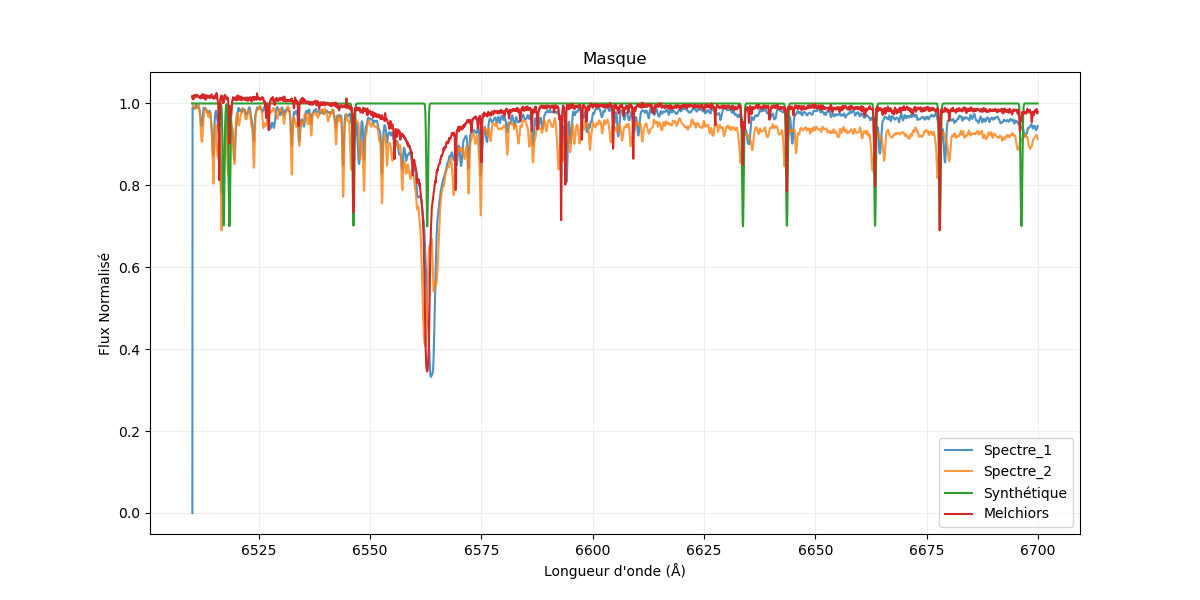

In [59]:

spec_name = "data/12Boo/F8IV_melchiors_417802.fits"
spec = Spectrum.read(spec_name)
db.show_spectrum(spec.spectral_axis, spec.flux, label='F8IV')


# On récupère les données de deux spectres
entry_test = data_list[6]
wave_obs = entry_test['spec'].wavelength.value
flux_obs = entry_test['spec'].flux.value

melchiors_flux = load_template('data/12Boo/F8IV_melchiors_417802.fits', wave_obs)
mask_flux = generate_synthetic_mask(wave_obs, synth_lines)

# On vérifie visuellement que le masque permet de repérer des raies du spectres NON TELLURIQUES !
plt.figure(figsize=(12, 6))
plt.plot(data_list[3]['spec'].wavelength.value, data_list[3]['spec'].flux.value / np.max(data_list[3]['spec'].flux.value), label='Spectre_1', alpha=0.8)
plt.plot(data_list[6]['spec'].wavelength.value, data_list[6]['spec'].flux.value / np.max(data_list[6]['spec'].flux.value), label='Spectre_2', alpha=0.8)
plt.plot(wave_obs, mask_flux, label='Synthétique', lw=1.5) #, ls='--')
plt.plot(wave_obs, melchiors_flux+0.2, label='Melchiors', lw=1.5) #, ls='--')

plt.title(f"Masque")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux Normalisé")
plt.legend()
#plt.xlim(6450, 6700)
#plt.ylim(0.4, 1.1)
plt.grid(alpha=0.2)
plt.show()

# analyse - méthode BF


In [60]:
def get_barycentric_correction(jd_utc):
    """Correction de la vitesse de la Terre (Rennes -> 12 Boo)"""
    t = Time(jd_utc, format='jd', scale='utc')
    vcorr = target.radial_velocity_correction(kind='barycentric', obstime=t, location=location)
    return vcorr.to(u.km / u.s)

def compute_broadening_function(observed_flux, template_flux, vel_width=150):
    """
    Calcule la Broadening Function (BF) par Décomposition en Valeurs Singulières (SVD).
    
    Args:
        observed_flux: Spectre de l'étoile (normalisé)
        template_flux: Masque synthétique (normalisé)
        vel_width: Largeur de la fenêtre de recherche en pixels
        
    Returns:
        v_axis: Axe des vitesses en km/s
        bf: Intensité de la BF
    """
    # Synchronisation des tailles et centrage
    n = min(len(observed_flux), len(template_flux))
    o = observed_flux[:n] - np.mean(observed_flux[:n])
    t = template_flux[:n] - np.mean(template_flux[:n])
    
    # Construction de la matrice de design (M)
    m = 2 * vel_width + 1
    M = np.zeros((n, m))
    for i in range(m):
        M[:, i] = np.roll(t, i - vel_width)
    
    # Résolution SVD et filtrage du bruit
    U, S, Vh = svd(M, full_matrices=False)
    S_inv = np.where(S > 0.05 * np.max(S), 1/S, 0) # Seuil de troncature
    
    # Reconstruction
    bf = Vh.T @ np.diag(S_inv) @ U.T @ o
    v_axis = (np.arange(m) - vel_width) * V_PIX
    
    return v_axis, bf

# =============================================================================
# 3. MODÉLISATION ORBITALE
# =============================================================================

def solve_kepler(M, e, tol=1e-10):
    e = np.clip(e, 0.0, 0.9999)  # ← évite e≥1 pendant l'optimisation
    E = M.copy() if hasattr(M, 'copy') else np.array([M])
    for _ in range(50):
        dE = (M - E + e * np.sin(E)) / (1 - e * np.cos(E))
        E += dE
        if np.max(np.abs(dE)) < tol:
            break
    return E

def rv_kepler(t, t0, P, K, e, omega_deg, gamma):
    """
    VR keplerienne exacte.
    t, t0 : JD
    K     : demi-amplitude km/s (toujours positif)
    omega : argument du périastre de l'étoile (degrés)
    """
    t = np.atleast_1d(np.array(t, dtype=float))
    omega = np.radians(omega_deg)
    M = 2 * np.pi * ((t - t0) % P) / P
    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(
        np.sqrt(1 + e) * np.sin(E / 2),
        np.sqrt(1 - e) * np.cos(E / 2)
    )
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def rv_kepler_scalar(t, t0, P, K, e, omega_deg, gamma):
    """Version scalaire pour curve_fit."""
    return rv_kepler(np.atleast_1d(t), t0, P, K, e, omega_deg, gamma)

def fit_rv_curve(jd_arr, vr_arr, P_fixed, is_star_b=False):
    """
    Fit keplérien exact. P est fixé, 5 paramètres libres : t0, K, e, omega, gamma.
    """
    # Nettoyage des NaN
    good = ~np.isnan(vr_arr)
    jd_fit, vr_fit = jd_arr[good], vr_arr[good]
    
    if len(jd_fit) < 5:
        raise ValueError(f"Pas assez de points : {len(jd_fit)}")

    # Valeurs initiales
    omega0 = 190.0 if not is_star_b else 10.0   # omega_B = omega_A + 180°
    p0 = [T0_REF, 70.0, 0.19, omega0, -11.0]
    
    # Bornes
    bl = [T0_REF - P_fixed, 40.0, 0.05, omega0 - 80, -25.0]
    bh = [T0_REF + P_fixed, 110.0, 0.35, omega0 + 80,   5.0]
    
    def model(t, t0, K, e, omega, gamma):
        return rv_kepler_scalar(t, t0, P_fixed, K, e, omega, gamma)
    
    popt, pcov = curve_fit(
        model, jd_fit, vr_fit,
        p0=p0, bounds=(bl, bh),
        max_nfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

def calculate_masses(K_A, K_B, period_days, eccentricity):
    G = 6.67430e-11
    P_sec = period_days * 86400
    ka_ms = abs(K_A) * 1000
    kb_ms = abs(K_B) * 1000
    factor = (P_sec / (2 * np.pi * G)) * (1 - eccentricity**2)**1.5
    ma = factor * (ka_ms + kb_ms)**2 * kb_ms / 1.98847e30
    mb = factor * (ka_ms + kb_ms)**2 * ka_ms / 1.98847e30
    return ma, mb
    

In [61]:
from scipy.optimize import curve_fit

def rotational_profile(v, v0, amp, vsini, epsilon=0.6):
    """
    Profil d'élargissement rotationnel de Gray (1992).
    epsilon : coefficient de brunissement aux bords (limb darkening)
    """
    x = (v - v0) / vsini
    mask = np.abs(x) < 1.0
    profile = np.zeros_like(v)
    profile[mask] = amp * (
        2 * (1 - epsilon) * np.sqrt(1 - x[mask]**2)
        + 0.5 * np.pi * epsilon * (1 - x[mask]**2)
    ) / (np.pi * vsini * (1 - epsilon/3))
    return profile

def double_rotational_profile(v, v0a, ampa, vsinia, v0b, ampb, vsinib):
    return rotational_profile(v, v0a, ampa, vsinia) + \
           rotational_profile(v, v0b, ampb, vsinib)

def fit_bf_peaks(v_axis, bf, v_target_a, v_target_b, vsini_init=15.0):
    """
    Ajuste deux profils rotationnels sur la BF.
    Retourne (va, vb) ou (nan, nan) si le fit échoue.
    """
    # Fenêtre de recherche élargie autour des cibles théoriques
    #search_half = 60  # km/s
    search_half = 80  # élargi de 60 à 80 km/s
    threshold_pcov = 30  # élargi de 20 à 30 km/s

    
    # Estimation initiale de l'amplitude : max de la BF près de chaque cible
    def peak_amp_near(vtarget):
        idx = np.abs(v_axis - vtarget) < search_half
        if not idx.any():
            return np.max(bf) * 0.5
        return np.max(bf[idx])
    
    amp_a0 = peak_amp_near(v_target_a)
    amp_b0 = peak_amp_near(v_target_b)
    
    separation = abs(v_target_a - v_target_b)
    
    if separation < 25:
        # Conjonction : pics fusionnés, on ajuste un seul profil
        try:
            p0 = [(v_target_a + v_target_b) / 2, (amp_a0 + amp_b0) / 2, vsini_init]
            """
            bounds = (
                [min(v_target_a, v_target_b) - 40, 0, 5],
                [max(v_target_a, v_target_b) + 40, np.max(bf) * 2, 60]
            )
            """
            bounds = (
                [v_target_a - search_half, 0, 8],
                [v_target_a + search_half, np.max(bf) * 2, 80]
            )
            popt, _ = curve_fit(
                lambda v, v0, amp, vs: rotational_profile(v, v0, amp, vs),
                v_axis, bf, p0=p0, bounds=bounds, maxfev=2000
            )
            return popt[0], np.nan  # on attribue à A, B inconnu
        except Exception:
            return np.nan, np.nan
    else:
        # Séparation suffisante : fit double
        try:
            p0 = [v_target_a, amp_a0, vsini_init,
                  v_target_b, amp_b0, vsini_init]
            bounds = (
                [v_target_a - search_half, 0, 5,
                 v_target_b - search_half, 0, 5],
                [v_target_a + search_half, np.max(bf) * 2, 60,
                 v_target_b + search_half, np.max(bf) * 2, 60]
            )
            popt, pcov = curve_fit(
                double_rotational_profile,
                v_axis, bf, p0=p0, bounds=bounds, maxfev=5000
            )
            # Vérification qualité : écart-type des paramètres
            perr = np.sqrt(np.diag(pcov))
            va = popt[0] if perr[0] < 20 else np.nan
            vb = popt[3] if perr[3] < 20 else np.nan
            return va, vb
        except Exception:
            # Fallback : un seul profil sur le pic dominant
            try:
                i_max = np.argmax(bf)
                p0 = [v_axis[i_max], np.max(bf), vsini_init]
                popt, _ = curve_fit(
                    lambda v, v0, amp, vs: rotational_profile(v, v0, amp, vs),
                    v_axis, bf, p0=p0, maxfev=1000
                )
                # Attribuer au plus proche des deux cibles
                if abs(popt[0] - v_target_a) < abs(popt[0] - v_target_b):
                    return popt[0], np.nan
                else:
                    return np.nan, popt[0]
            except Exception:
                return np.nan, np.nan


def fit_rv_curve(jd_arr, vr_arr, P_fixed, is_star_b=False):
    jd_arr = np.array(jd_arr, dtype=float)
    vr_arr = np.array(vr_arr, dtype=float)
    
    # Étape 1 : filtre NaN/inf
    good = np.isfinite(vr_arr)
    jd_fit, vr_fit = jd_arr[good], vr_arr[good]
    
    # Étape 2 : rejet des outliers (> 2.5 MAD de la médiane)
    median_v = np.median(vr_fit)
    mad = np.median(np.abs(vr_fit - median_v))
    inliers = np.abs(vr_fit - median_v) < 2.5 * mad + 20  # +20 km/s marge
    jd_fit, vr_fit = jd_fit[inliers], vr_fit[inliers]
    
    if len(jd_fit) < 5:
        raise ValueError(f"Pas assez de points après nettoyage : {len(jd_fit)}")
    
    print(f"  {'B' if is_star_b else 'A'} : {len(jd_fit)} points utilisés sur {good.sum()}")
    
    omega0 = 190.0 if not is_star_b else 10.0
    p0 = [T0_REF, 70.0, 0.19, omega0, -11.0]
    bl = [T0_REF - P_fixed, 40.0, 0.05, omega0 - 80, -25.0]
    bh = [T0_REF + P_fixed, 110.0, 0.35, omega0 + 80,   5.0]
    
    def model(t, t0, K, e, omega, gamma):
        return rv_kepler_scalar(t, t0, P_fixed, K, e, omega, gamma)
    
    popt, pcov = curve_fit(
        model, jd_fit, vr_fit,
        p0=p0, bounds=(bl, bh),
        max_nfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

Template offset H-alpha : -14.2 km/s → correction appliquée

JD             | φ      | VR_A (km/s)   | VR_B (km/s)   | sep (km/s)
----------------------------------------------------------------------
2460843.46841  | 0.924 |      -54.51  |       63.24  | 146.3
2460844.43400  | 0.024 |      -70.31  |       74.57  | 153.9
2460845.40259  | 0.125 |      -46.73  |       50.04  | 65.9
2460846.40154  | 0.230 |       16.80  |        1.99  | 31.3
2460847.40213  | 0.334 |        0.67  |      -80.75  | 90.3
2460848.39672  | 0.438 |       47.14  |      -32.97  | 112.3
2460849.41439  | 0.544 |       67.07  |      -49.85  | 103.8
2460850.39917  | 0.646 |       20.14  |      -58.76  | 67.5
2460851.37702  | 0.748 |      -35.57  |         nan  | 2.5
2460853.40556  | 0.960 |      -63.88  |       71.19  | 162.2
2460854.42253  | 0.066 |      -69.13  |       62.30  | 124.7
2460855.39118  | 0.167 |      -34.92  |         nan  | 23.7
2460856.40122  | 0.272 |        1.93  |         nan  | 60.3


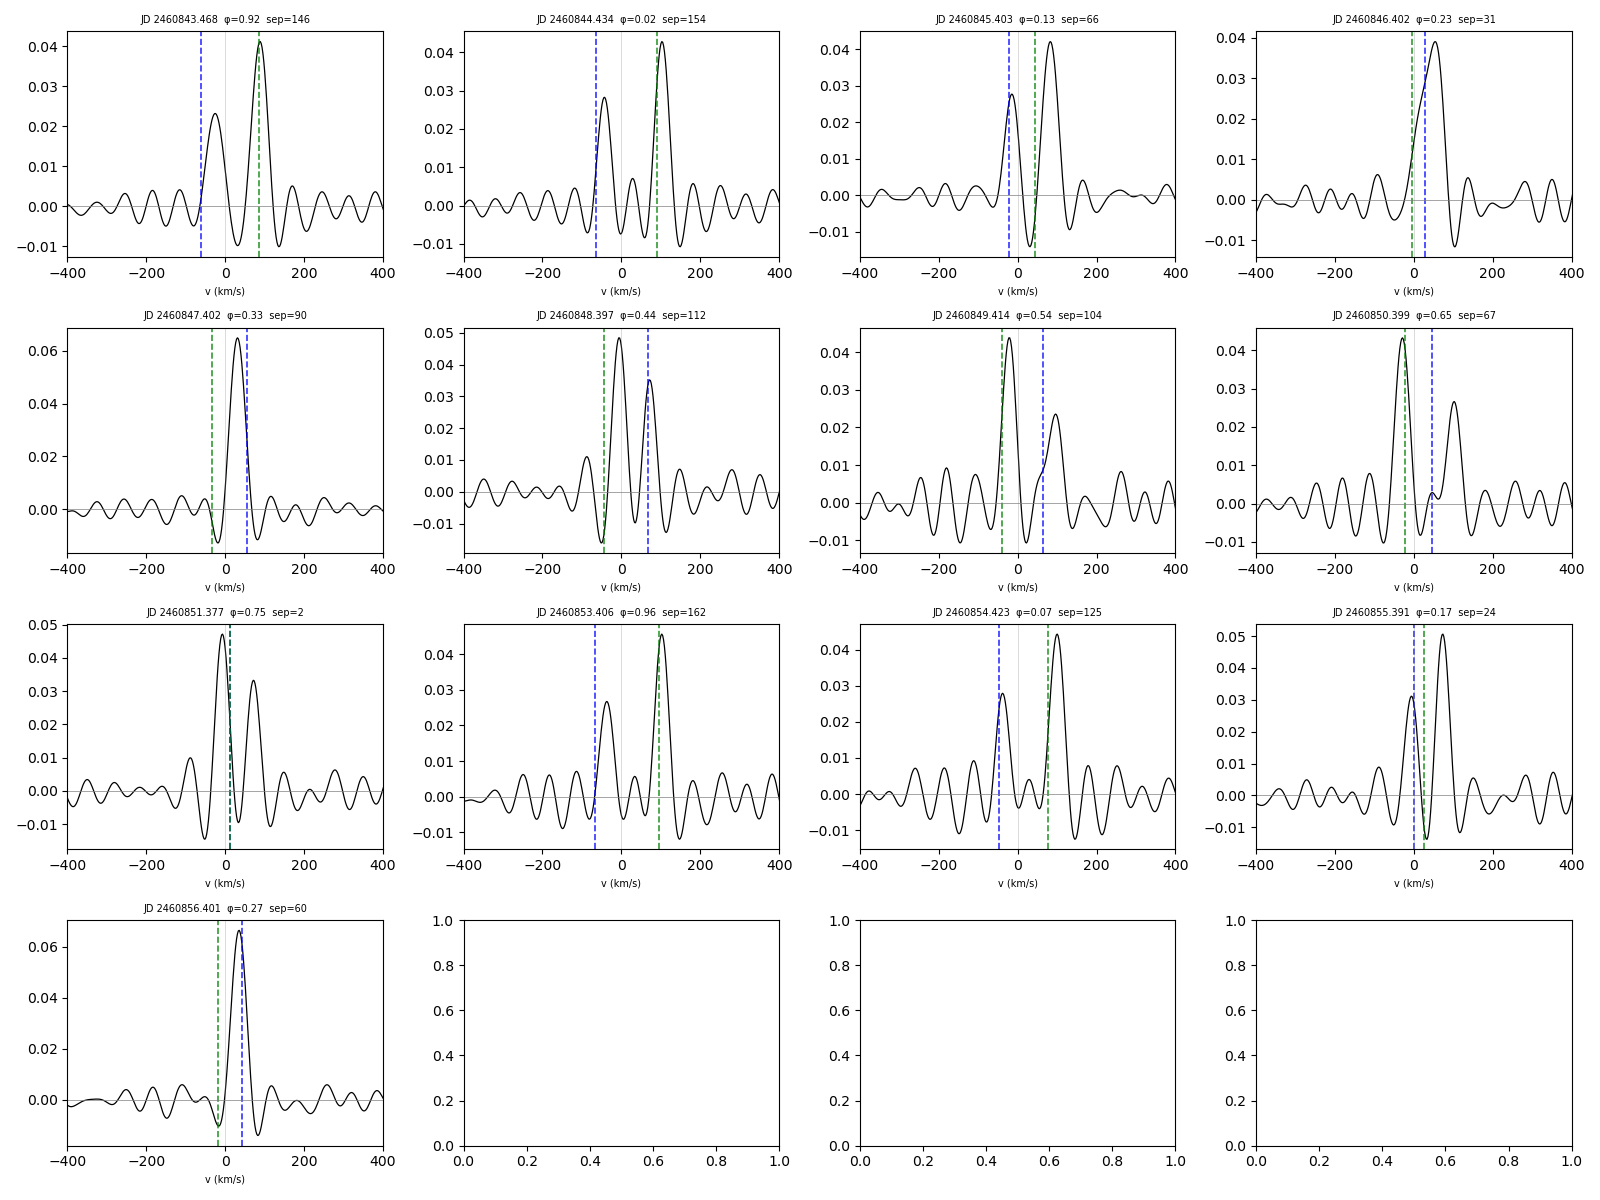

  A : 13 points utilisés sur 13
  B : 10 points utilisés sur 10

Vérification : omega_B - omega_A = 265.3° (attendu ~180°)


/var/folders/r1/s24q5jr91lgb5xgp830lvyj80000gn/T/ipykernel_71396/1257469997.py:68: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(1 - e) * np.cos(E / 2)


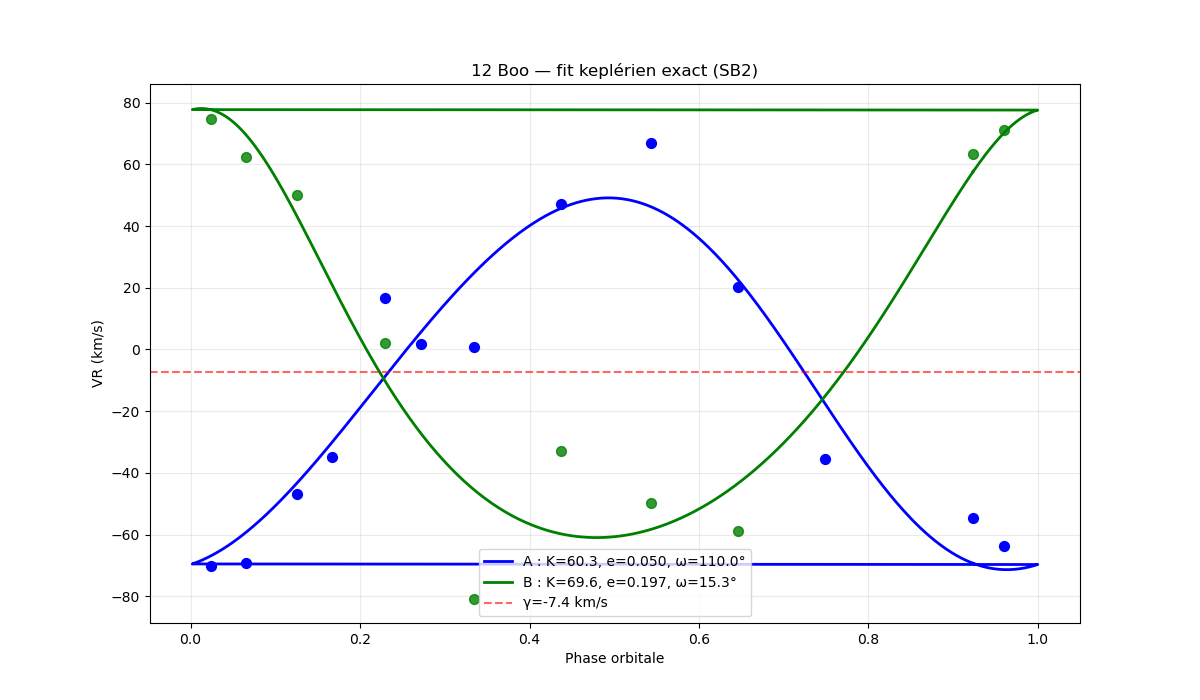


PARAMÈTRES ORBITAUX (fit keplérien exact)
Période fixée   P   = 9.5910 j
Excentricité    e   = 0.124  (A:0.050 / B:0.197)
Vit. systémique γ   = -7.39 km/s
Demi-amplitude  K_A = 60.27 ± 7.14 km/s
Demi-amplitude  K_B = 69.56 ± 9.01 km/s
Arg. périastre  ω_A = 110.0°  ω_B = 15.3°  Δ=265.3°
T0 (périastre)  t0  = 2460842.1246 JD
----------------------------------------
M_A sin³i = 1.139 M☉
M_B sin³i = 0.986 M☉


In [66]:
# ============================================================
# CHARGEMENT TEMPLATE 
# ============================================================
wave_ref = data_list[0]['spec'].wavelength.value
melchiors_raw = load_template('data/12Boo/F8IV_melchiors_417802.fits', wave_ref)
melchiors_norm = melchiors_raw / np.percentile(melchiors_raw, 95) - 1.0
sigma_px = (0.44 / 2.355) / DISP
melchiors_conv = gaussian_filter1d(melchiors_norm, sigma=sigma_px)
mask_template = -melchiors_conv   # raies positives pour SVD

# ============================================================
# BOUCLE BF
# ============================================================
results_A, results_B, jd_list, phases = [], [], [], []

print(f"\n{'JD':<14} | {'φ':<6} | {'VR_A (km/s)':<13} | {'VR_B (km/s)':<13} | {'sep (km/s)'}")
print("-" * 70)

fig_bf, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, entry in enumerate(data_list):
    wave = entry['spec'].wavelength.value
    flux_raw = entry['spec'].flux.value
    jd = entry['jd']

    # Normalisation
    obs_flux = flux_raw / np.percentile(flux_raw, 95) - 1.0

    # Template interpolé sur la grille courante si nécessaire
    if not np.array_equal(wave, wave_ref):
        f_interp = interp1d(wave_ref, mask_template, bounds_error=False, fill_value=0)
        mask_flux = f_interp(wave)
    else:
        mask_flux = mask_template

    # BF
    v_axis, bf = compute_broadening_function(obs_flux, mask_flux, vel_width=200)
    bf = -bf

    # Correction barycentrique
    v_bary = get_barycentric_correction(jd).value

    # Phase et cibles théoriques (kepler exact avec params de référence)
    ph = ((jd - T0_REF) % P) / P
    
    # Cibles dans le référentiel BF (avant correction barycentrique)
    vta_bfref = rv_kepler(jd, T0_REF, P, K_A, E_REF, OMEGA_REF, GAMMA_REF)[0] - v_bary
    vtb_bfref = rv_kepler(jd, T0_REF, P, K_B, E_REF, OMEGA_REF + 180, GAMMA_REF)[0] - v_bary
    sep = abs(vta_bfref - vtb_bfref)

    # Fit double profil
    va, vb = fit_bf_peaks(v_axis, bf, vta_bfref, vtb_bfref)

    # Correction barycentrique + offset instrumental
    if not np.isnan(va):
        va += v_bary + OFFSET_INST
    if not np.isnan(vb):
        vb += v_bary + OFFSET_INST

    print(f"{jd:.5f}  | {ph:.3f} | {va:11.2f}  | {vb:11.2f}  | {sep:.1f}")

    results_A.append(va)
    results_B.append(vb)
    jd_list.append(jd)
    phases.append(ph)

    # Plot diagnostic individuel
    if i < len(axes):
        ax = axes[i]
        ax.plot(v_axis, bf, 'k-', lw=0.9)
        ax.axvline(vta_bfref, color='blue',  lw=1.2, ls='--', alpha=0.8)
        ax.axvline(vtb_bfref, color='green', lw=1.2, ls='--', alpha=0.8)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlim(-200, 200)
        ax.set_title(f"JD {jd:.3f}  φ={ph:.2f}  sep={sep:.0f}", fontsize=7)
        ax.set_xlabel('v (km/s)', fontsize=7)
        ax.set_xlim(-400, 400)

plt.tight_layout()
plt.savefig('images/bf_individual.png', dpi=120)
plt.show()

# ============================================================
# FIT ORBITAL KEPLER EXACT
# ============================================================
jd_arr      = np.array(jd_list)
results_A_np = np.array(results_A)
results_B_np = np.array(results_B)
phases_np    = np.array(phases)

try:
    popt_A, perr_A = fit_rv_curve(jd_arr, results_A_np, P_fixed=P, is_star_b=False)
    popt_B, perr_B = fit_rv_curve(jd_arr, results_B_np, P_fixed=P, is_star_b=True)
except ValueError as err:
    print(f"Fit impossible : {err}")
    raise

t0_A, K_A_fit, e_A, omega_A, gamma_A = popt_A
t0_B, K_B_fit, e_B, omega_B, gamma_B = popt_B

# Vérification cohérence omega
delta_omega = (omega_B - omega_A) % 360
print(f"\nVérification : omega_B - omega_A = {delta_omega:.1f}° (attendu ~180°)")

# Courbes modèles sur grille temporelle fine
t_plot = np.linspace(jd_arr.min(), jd_arr.min() + P, 500)
ph_plot = ((t_plot - T0_REF) % P) / P
v_A_plot = rv_kepler(t_plot, *popt_A, P)
v_B_plot = rv_kepler(t_plot, *popt_B, P)

# Correction : rv_kepler prend (t, t0, P, K, e, omega, gamma)
v_A_plot = rv_kepler(t_plot, popt_A[0], P, popt_A[1], popt_A[2], popt_A[3], popt_A[4])
v_B_plot = rv_kepler(t_plot, popt_B[0], P, popt_B[1], popt_B[2], popt_B[3], popt_B[4])

mask_a = ~np.isnan(results_A_np)
mask_b = ~np.isnan(results_B_np)

plt.figure(figsize=(12, 7))
plt.plot(ph_plot, v_A_plot, 'b-', lw=2, label=f'A : K={K_A_fit:.1f}, e={e_A:.3f}, ω={omega_A:.1f}°')
plt.plot(ph_plot, v_B_plot, 'g-', lw=2, label=f'B : K={K_B_fit:.1f}, e={e_B:.3f}, ω={omega_B:.1f}°')
plt.axhline((gamma_A + gamma_B) / 2, color='red', ls='--', alpha=0.6, label=f'γ={((gamma_A+gamma_B)/2):.1f} km/s')
plt.scatter(phases_np[mask_a], results_A_np[mask_a], color='blue',  s=50, zorder=3)
plt.scatter(phases_np[mask_b], results_B_np[mask_b], color='green', s=50, zorder=3, alpha=0.8)
plt.xlabel('Phase orbitale')
plt.ylabel('VR (km/s)')
plt.title('12 Boo — fit keplérien exact (SB2)')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ============================================================
# RÉSULTATS FINAUX
# ============================================================
ma, mb = calculate_masses(K_A_fit, K_B_fit, P, (e_A + e_B) / 2)
e_mean = (e_A + e_B) / 2
gamma_mean = (gamma_A + gamma_B) / 2

print("\n" + "=" * 40)
print("PARAMÈTRES ORBITAUX (fit keplérien exact)")
print("=" * 40)
print(f"Période fixée   P   = {P:.4f} j")
print(f"Excentricité    e   = {e_mean:.3f}  (A:{e_A:.3f} / B:{e_B:.3f})")
print(f"Vit. systémique γ   = {gamma_mean:.2f} km/s")
print(f"Demi-amplitude  K_A = {K_A_fit:.2f} ± {perr_A[1]:.2f} km/s")
print(f"Demi-amplitude  K_B = {K_B_fit:.2f} ± {perr_B[1]:.2f} km/s")
print(f"Arg. périastre  ω_A = {omega_A:.1f}°  ω_B = {omega_B:.1f}°  Δ={delta_omega:.1f}°")
print(f"T0 (périastre)  t0  = {t0_A:.4f} JD")
print("-" * 40)
print(f"M_A sin³i = {ma:.3f} M☉")
print(f"M_B sin³i = {mb:.3f} M☉")
print("=" * 40)

# analyse - méthode CCF


JD           | VR_Abs (km/s)
----------------------------------------
2460843.46841 |      64.39
2460844.43400 |      79.77
2460845.40259 |      60.50
2460846.40154 |      30.91
2460847.40213 |       6.94
2460848.39672 |     -28.70
2460849.41439 |     -46.25
2460850.39917 |     -52.23
2460851.37702 |     -31.14
2460853.40556 |      79.29
2460854.42253 |      76.74
2460855.39118 |      47.54
2460856.40122 |      10.52


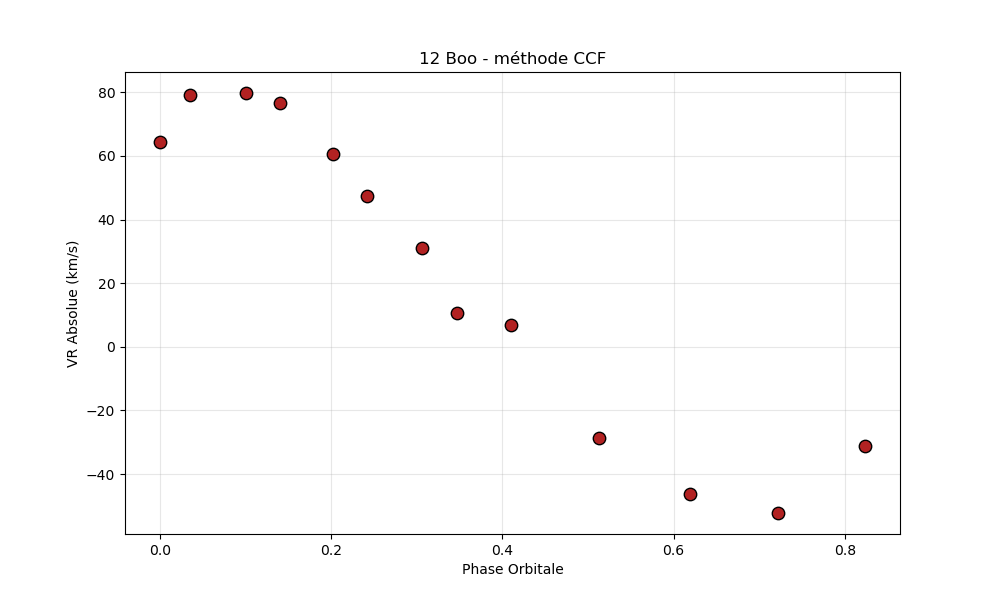

In [9]:
def find_precise_peak(lag, corr):
    """Ajuste une parabole sur le sommet pour une précision sub-pixel"""
    i_max = np.argmax(corr)
    if i_max <= 0 or i_max >= len(corr) - 1:
        return lag[i_max].value
    x = lag[i_max-1 : i_max+2].value
    y = corr[i_max-1 : i_max+2]
    f = np.polyfit(x, y, 2)
    return -f[1] / (2 * f[0])

wave_obs = data_list[0]['spec'].spectral_axis.value

flux_model = generate_synthetic_mask(wave_obs, synth_lines)
tspec_model = Spectrum(flux=flux_model * u.dimensionless_unscaled,
                       spectral_axis=wave_obs * u.AA)


# ---------------------------------------------------------
results = []
print(f"\n{'JD':<12} | {'VR_Abs (km/s)':<12}")
print("-" * 40)


for i, entry in enumerate(data_list):
    
    # On normalise et on retire la moyenne (pour que le continuum soit à 0)
    obs_flux = entry['spec'].flux.value
    obs_flux = obs_flux / np.percentile(obs_flux, 95) - 1.0 
    
    spec_to_corr = Spectrum(flux=obs_flux * u.dimensionless_unscaled,
                            spectral_axis=entry['spec'].spectral_axis)
    
    # Corrélation avec le masque théorique
    #corr, lag = correlation.template_correlate(spec_to_corr, tspec_model)
    corr, lag = correlation.template_correlate(1.0 - entry['spec'], 1.0 - tspec_model)
    #print(f"Décalage min/max du lag : {lag.min()} / {lag.max()}")
    
    v_rel = find_precise_peak(lag, corr)
    v_bary = get_barycentric_correction(entry['jd']).value
    vr_abs = v_rel + v_bary
    
    results.append({'jd': entry['jd'], 'vr': vr_abs})
    print(f"{entry['jd']:.5f} | {vr_abs:10.2f}")

# 6. GRAPHIQUE FINAL (COURBE DE PHASE)
# ---------------------------------------------------------
jd_arr = np.array([r['jd'] for r in results])
vr_arr = np.array([r['vr'] for r in results])

P = 9.6045 
T0 = jd_arr[0]
phases = ((jd_arr - T0) % P) / P

plt.figure(figsize=(10, 6))
plt.scatter(phases, vr_arr, color='firebrick', s=80, edgecolors='k', zorder=3)
#plt.axhline(-10.5, color='gray', linestyle='--', label='Vitesse systémique')
plt.title("12 Boo - méthode CCF")
plt.xlabel("Phase Orbitale")
plt.ylabel("VR Absolue (km/s)")
plt.grid(alpha=0.3)
plt.show()


# tests avec BinaryStarSolve

In [71]:

# first value being the time in Reduced Julian Date (RJD), 
# the second being the radial velocity of the primary star in km/s, 
# the third being the radial velocity of the secondary star in km/s, 
# and the fourth and fifth (optional) values being the respective weights of the primary and second star's radial velocities.

output_ccf = 'data/rvs_ccf_output.txt'
rvs_list = np.array([
[2460843.46841 ,  63.77],
[2460844.43400 ,  78.74],
[2460845.40259 ,  60.38],
[2460846.40154 ,  28.93],
[2460847.40213 ,   7.26],
[2460848.39672 , -28.22],
[2460849.41439 , -46.42],
[2460850.39917 , -52.55],
[2460851.37702 , -30.34],
[2460853.40556 ,  77.03],
[2460854.42253 ,  73.76],
[2460855.39118 ,  47.85],
[2460856.40122 ,  10.00],
])

# 1. On réduit le JD (on enlève 2460840)
#rvs_list[:, 0] -= 2460840 

# 2. On sauvegarde dans un fichier temporaire propre
#np.savetxt(output_ccf, rvs_list, delimiter='\t')

np.savetxt(output_ccf, rvs_list, fmt=['%.5f', '%.2f'], delimiter='\t')

"""
JD           | VR_Abs (km/s)
----------------------------------------
2460843.46841 |      63.77
2460844.43400 |      78.74
2460845.40259 |      60.38
2460846.40154 |      28.93
2460847.40213 |       7.26
2460848.39672 |     -28.22
2460849.41439 |     -46.42
2460850.39917 |     -52.55
2460851.37702 |     -30.34
2460853.40556 |      77.03
2460854.42253 |      73.76
2460855.39118 |      47.85
2460856.40122 |      10.00

JD           | VR_A (km/s)  | VR_B (km/s) 
----------------------------------------
2460843.46841 |     -93.12|      65.08
2460844.43400 |     -97.69|      80.56
2460845.40259 |     -75.51|      62.63
2460846.40154 |     -13.28|        nan
2460847.40213 |       8.85|        nan
2460848.39672 |      46.59|        nan
2460849.41439 |      28.59|     -73.90
2460850.39917 |      30.72|     -56.18
2460851.37702 |     -31.76|        nan
2460853.40556 |     -98.88|      79.37
2460854.42253 |    -101.25|      77.00
2460855.39118 |     -32.22|      10.12
2460856.40122 |      18.92|     -43.47
"""


'\nJD           | VR_Abs (km/s)\n----------------------------------------\n2460843.46841 |      63.77\n2460844.43400 |      78.74\n2460845.40259 |      60.38\n2460846.40154 |      28.93\n2460847.40213 |       7.26\n2460848.39672 |     -28.22\n2460849.41439 |     -46.42\n2460850.39917 |     -52.55\n2460851.37702 |     -30.34\n2460853.40556 |      77.03\n2460854.42253 |      73.76\n2460855.39118 |      47.85\n2460856.40122 |      10.00\n\nJD           | VR_A (km/s)  | VR_B (km/s) \n----------------------------------------\n2460843.46841 |     -93.12|      65.08\n2460844.43400 |     -97.69|      80.56\n2460845.40259 |     -75.51|      62.63\n2460846.40154 |     -13.28|        nan\n2460847.40213 |       8.85|        nan\n2460848.39672 |      46.59|        nan\n2460849.41439 |      28.59|     -73.90\n2460850.39917 |      30.72|     -56.18\n2460851.37702 |     -31.76|        nan\n2460853.40556 |     -98.88|      79.37\n2460854.42253 |    -101.25|      77.00\n2460855.39118 |     -32.22|      

Finding initial guesses...
Minimizing...


NameError: name 'params' is not defined

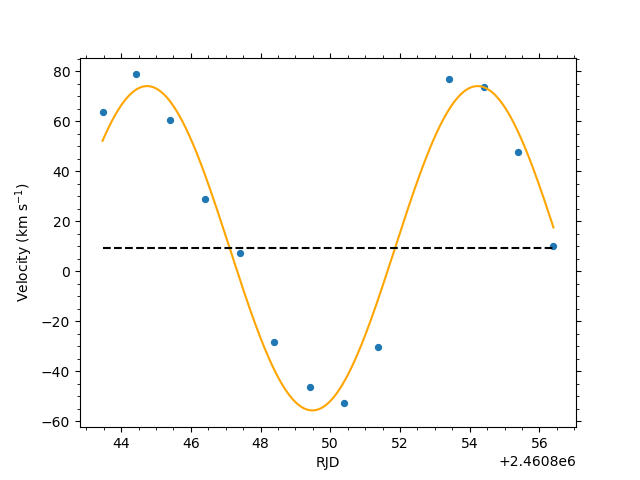

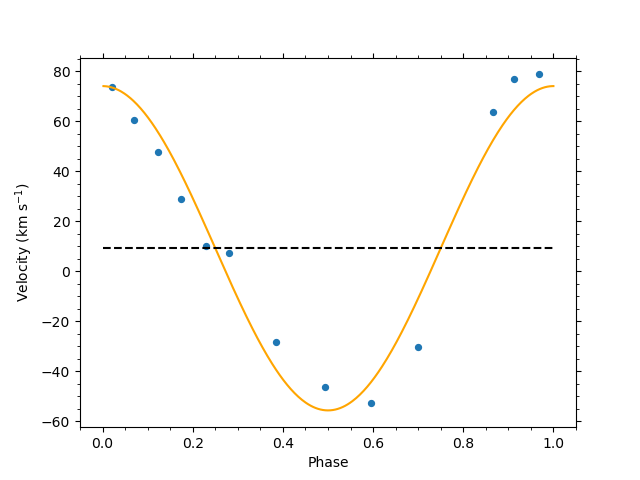

In [72]:
# Lancement du solver
# Essaye d'ajouter de la précision sur Pguess si tu la connais (9.591)
from binarystarsolve import StarSolve
param, err = StarSolve(output_ccf, star="primary", Pguess=9.591, zeroEcc=True, graphs=True)

print(type(params)) # Pour voir si c'est une liste ou un dictionnaire
print(params)       # Pour voir l'ordre des valeurs

gamma_val = params[0]
k_val = params[1]
e_val = params[2]

print(f"Gamma : {gamma_val:.2f} km/s")
print(f"K     : {k_val:.2f} km/s")
print(f"e     : {e_val:.3f}")

Tentative de fit...
Finding initial guesses...
Minimizing...


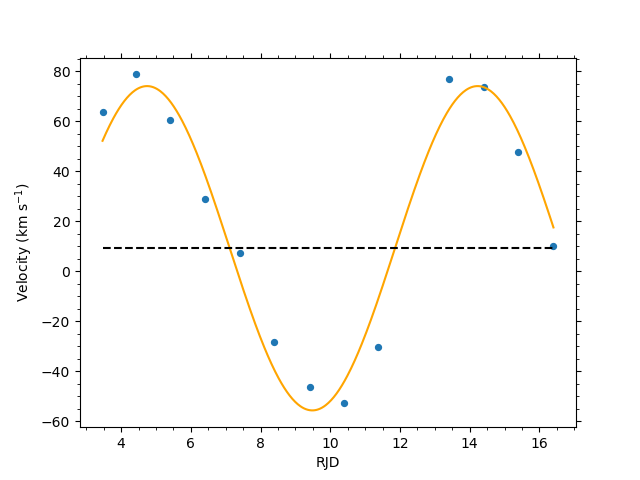

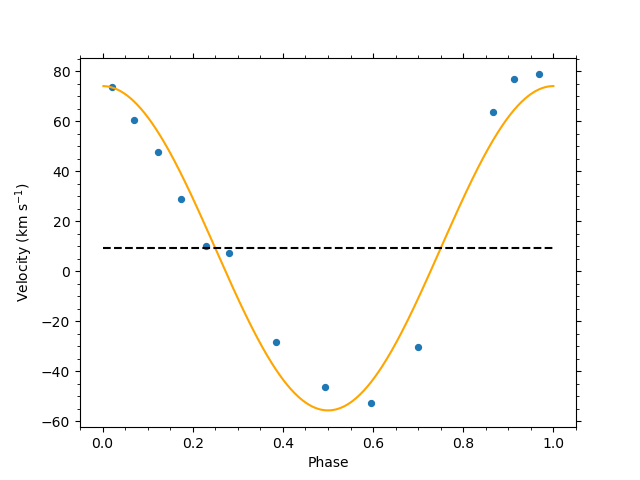

In [73]:
data_ccf = np.array([
    [3.468, 63.77], [4.434, 78.74], [5.403, 60.38], [6.402, 28.93],
    [7.402, 7.26], [8.397, -28.22], [9.414, -46.42], [10.399, -52.55],
    [11.377, -30.34], [13.406, 77.03], [14.423, 73.76], [15.391, 47.85],
    [16.401, 10.00]
])

# Sauvegarde en format standard (float simple)
df = pd.DataFrame(data_ccf)
df.to_csv('ccf_final.txt', sep='\t', index=False, header=False, float_format='%.4f')

# Tentative avec zeroEcc=True pour éviter le crash de la SVD
# Si l'excentricité pose problème, on la fixe à 0 pour stabiliser le premier fit
try:
    print("Tentative de fit...")
    params, err = StarSolve('ccf_final.txt', 
                            star="primary", 
                            Pguess=9.59, 
                            zeroEcc=True, # On force circulaire pour éviter le crash
                            graphs=True)
except Exception as e:
    print(f"Erreur rencontrée : {e}")

In [74]:
from binarystarsolve import StarSolve
#StarSolve(output_ccf)

param, err = StarSolve(output_ccf, star = "both", Pguess = 9.6, zeroEcc = False, graphs = True) 


IndexError: index 2 is out of bounds for axis 1 with size 2

In [75]:


# Generate a fine phase grid for smooth curve
P = param[5]  # Orbital period
T0 = param[4]  # Time of periastron
phase = (time - T0) % P / P

# Sort by phase for plotting
sorted_idx = np.argsort(phase)
phase_sorted = phase[sorted_idx]
rv_sorted = rv[sorted_idx]

plt.figure()
plt.scatter(phase_sorted, rv_sorted, label="Data")
# Overlay best-fit model (you may need to compute model RVs using the params)
plt.xlabel("Orbital Phase")
plt.ylabel("Radial Velocity (km/s)")
plt.legend()
plt.title("RV Curve vs. Phase")
plt.show()

NameError: name 'time' is not defined

In [75]:
param[1]

array([2.79535534e+00, 5.28140000e+01, 1.80000000e+02, 0.00000000e+00,
       2.46085000e+06, 9.60000000e+00, 6.97190000e+00, 1.50140000e-01])

In [28]:
spec_m = Spectrum.read('data/12Boo/F8IV_melchiors_417802.fits')
wave_m = spec_m.meta['header']['CRVAL1'] + np.arange(len(spec_m.flux.value)) * spec_m.meta['header']['CDELT1']

# Zoom sur H-alpha dans le template
mask_ha = (wave_m > 6555) & (wave_m < 6575)
ha_center = wave_m[mask_ha][np.argmin(spec_m.flux.value[mask_ha])]
print(f"Centre H-alpha dans Melchiors : {ha_center:.3f} Å  (attendu : 6562.81 Å)")
print(f"Décalage : {(ha_center - 6562.81) / 6562.81 * 299792:.1f} km/s")

# Même chose sur un de tes spectres
wave_obs = data_list[6]['spec'].wavelength.value
flux_obs = data_list[6]['spec'].flux.value
mask_ha_obs = (wave_obs > 6555) & (wave_obs < 6575)
ha_center_obs = wave_obs[mask_ha_obs][np.argmin(flux_obs[mask_ha_obs])]
print(f"Centre H-alpha dans spectre obs JD6 : {ha_center_obs:.3f} Å")
print(f"Décalage : {(ha_center_obs - 6562.81) / 6562.81 * 299792:.1f} km/s")

Centre H-alpha dans Melchiors : 6562.500 Å  (attendu : 6562.81 Å)
Décalage : -14.2 km/s
Centre H-alpha dans spectre obs JD6 : 6562.371 Å
Décalage : -20.0 km/s


In [37]:
# Diagnostic des phases pour les JD avec NaN
problematic = [2460846.40154, 2460847.40213, 2460851.37702, 2460856.40122]
for jd in problematic:
    ph = ((jd - T0_REF) % P) / P
    vta = kepler_model(ph, K_A, E_REF, OMEGA_REF, GAMMA_REF)
    vtb = kepler_model(ph, K_B, E_REF, OMEGA_REF, GAMMA_REF)
    sep = abs(vta - vtb)
    print(f"JD {jd:.5f}  φ={ph:.3f}  V_A={vta:.1f}  V_B={vtb:.1f}  séparation={sep:.1f} km/s")

JD 2460846.40154  φ=0.230  V_A=-20.1  V_B=-0.5  séparation=19.6 km/s
JD 2460847.40213  φ=0.334  V_A=20.8  V_B=-42.9  séparation=63.7 km/s
JD 2460851.37702  φ=0.748  V_A=-34.4  V_B=14.3  séparation=48.7 km/s
JD 2460856.40122  φ=0.272  V_A=-2.2  V_B=-19.1  séparation=16.9 km/s


In [38]:
# Diagnostic ciblé sur les 2 JD problématiques
for entry in data_list:
    if entry['jd'] not in [2460847.40213, 2460851.37702]:
        continue
    
    wave = entry['spec'].wavelength.value
    flux_raw = entry['spec'].flux.value
    obs_flux = flux_raw / np.percentile(flux_raw, 95) - 1.0
    mask_flux = -melchiors_conv  # ton template déjà chargé
    
    v_axis, bf = compute_broadening_function(obs_flux, mask_flux)
    bf = -bf
    
    v_bary = get_barycentric_correction(entry['jd']).value
    ph = ((entry['jd'] - T0_REF) % P) / P
    vta = kepler_model(ph, K_A, E_REF, OMEGA_REF, GAMMA_REF)
    vtb = kepler_model(ph, K_B, E_REF, OMEGA_REF, GAMMA_REF)
    
    # Trouve les vrais maxima locaux au-dessus de 30% du max
    threshold = np.max(bf) * 0.30
    peaks_idx, props = find_peaks(bf, height=threshold, distance=8)
    
    print(f"\nJD {entry['jd']:.5f}  φ={ph:.3f}")
    print(f"  Cibles théoriques (dans ref BF) : A={vta - v_bary:.1f}  B={vtb - v_bary:.1f} km/s")
    print(f"  Pics détectés dans la BF :")
    for idx in peaks_idx:
        print(f"    v={v_axis[idx]:.1f} km/s  amp={bf[idx]:.4f}")


JD 2460847.40213  φ=0.334
  Cibles théoriques (dans ref BF) : A=43.1  B=-20.6 km/s
  Pics détectés dans la BF :
    v=33.4 km/s  amp=0.0703

JD 2460851.37702  φ=0.748
  Cibles théoriques (dans ref BF) : A=-11.5  B=37.1 km/s
  Pics détectés dans la BF :
    v=-6.7 km/s  amp=0.0507
    v=69.1 km/s  amp=0.0316


In [54]:
# Diagnostic rapide des points B aberrants
phases_b = phases_np[~np.isnan(results_B_np)]
vr_b     = results_B_np[~np.isnan(results_B_np)]
for ph, vr in zip(phases_b, vr_b):
    print(f"φ={ph:.3f}  VR_B={vr:.1f} km/s")

φ=0.924  VR_B=66.1 km/s
φ=0.024  VR_B=82.8 km/s
φ=0.125  VR_B=65.8 km/s
φ=0.230  VR_B=24.9 km/s
φ=0.544  VR_B=-46.0 km/s
φ=0.646  VR_B=-49.7 km/s
φ=0.960  VR_B=77.2 km/s
φ=0.066  VR_B=75.8 km/s


In [63]:
def extract_all_vr(data_list, mask_template, wave_ref, 
                   t0, P, K_A, K_B, e, omega_A, gamma):
    """
    Extrait les VR de tous les spectres avec des cibles théoriques données.
    Retourne jd_arr, vr_A, vr_B, phases, separations
    """
    results_A, results_B, jd_list, phases, seps = [], [], [], [], []
    
    for entry in data_list:
        wave = entry['spec'].wavelength.value
        flux_raw = entry['spec'].flux.value
        jd = entry['jd']
        
        obs_flux = flux_raw / np.percentile(flux_raw, 95) - 1.0
        
        if not np.array_equal(wave, wave_ref):
            f_interp = interp1d(wave_ref, mask_template, 
                               bounds_error=False, fill_value=0)
            mask_flux = f_interp(wave)
        else:
            mask_flux = mask_template
        
        v_axis, bf = compute_broadening_function(obs_flux, mask_flux)
        bf = -bf
        v_bary = get_barycentric_correction(jd).value
        ph = ((jd - t0) % P) / P
        
        # Cibles dans le référentiel BF avec les paramètres courants
        vta = rv_kepler(np.array([jd]), t0, P, K_A, e, omega_A,     gamma)[0]
        vtb = rv_kepler(np.array([jd]), t0, P, K_B, e, omega_A+180, gamma)[0]
        vta_bfref = vta - v_bary
        vtb_bfref = vtb - v_bary
        sep = abs(vta_bfref - vtb_bfref)
        
        va, vb = fit_bf_peaks(v_axis, bf, vta_bfref, vtb_bfref)
        
        if not np.isnan(va): va += v_bary
        if not np.isnan(vb): vb += v_bary
        
        results_A.append(va)
        results_B.append(vb)
        jd_list.append(jd)
        phases.append(ph)
        seps.append(sep)
    
    return (np.array(jd_list), np.array(results_A), 
            np.array(results_B), np.array(phases), np.array(seps))


def iterate_orbital_solution(data_list, mask_template, wave_ref,
                              P_fixed, n_iter=4,
                              sep_min=40.0):
    """
    Itère extraction VR + fit orbital jusqu'à convergence.
    sep_min : séparation minimale (km/s) pour utiliser un point dans le fit
    """
    # Paramètres initiaux : solution pro comme point de départ
    t0    = T0_REF
    K_A   = 68.2
    K_B   = 70.8
    e     = E_REF
    omega = OMEGA_REF
    gamma = GAMMA_REF
    
    history = []
    
    for iteration in range(n_iter):
        print(f"\n{'='*50}")
        print(f"ITÉRATION {iteration+1}")
        print(f"  Paramètres courants : K_A={K_A:.1f} K_B={K_B:.1f} "
              f"e={e:.3f} ω={omega:.1f}° γ={gamma:.2f}")
        print(f"{'='*50}")
        
        # Extraction des VR
        jd_arr, vr_A, vr_B, phases, seps = extract_all_vr(
            data_list, mask_template, wave_ref,
            t0, P_fixed, K_A, K_B, e, omega, gamma
        )
        
        # On n'utilise que les points bien séparés pour le fit
        good_sep = seps > sep_min
        
        print(f"  Points A exploitables (sep>{sep_min:.0f} km/s) : "
              f"{np.sum(good_sep & np.isfinite(vr_A))}")
        print(f"  Points B exploitables : "
              f"{np.sum(good_sep & np.isfinite(vr_B))}")
        
        # Fit orbital sur les points propres uniquement
        try:
            popt_A, perr_A = fit_rv_curve(
                jd_arr[good_sep], vr_A[good_sep], P_fixed, is_star_b=False)
            popt_B, perr_B = fit_rv_curve(
                jd_arr[good_sep], vr_B[good_sep], P_fixed, is_star_b=True)
        except ValueError as err:
            print(f"  Fit échoué : {err}")
            break
        
        # Mise à jour des paramètres
        t0_new, K_A_new, e_A_new, omega_A_new, gamma_A_new = popt_A
        _,      K_B_new, e_B_new, omega_B_new, gamma_B_new = popt_B
        
        e_new     = (e_A_new + e_B_new) / 2
        gamma_new = (gamma_A_new + gamma_B_new) / 2
        
        # Convergence ?
        delta_K_A = abs(K_A_new - K_A)
        delta_K_B = abs(K_B_new - K_B)
        delta_e   = abs(e_new - e)
        
        print(f"  Résultat : K_A={K_A_new:.2f}±{perr_A[1]:.2f}  "
              f"K_B={K_B_new:.2f}±{perr_B[1]:.2f}  "
              f"e={e_new:.3f}  γ={gamma_new:.2f}")
        print(f"  Δ(K_A)={delta_K_A:.2f}  Δ(K_B)={delta_K_B:.2f}  "
              f"Δ(e)={delta_e:.4f}")
        
        history.append({
            'K_A': K_A_new, 'K_B': K_B_new, 'e': e_new,
            'omega': omega_A_new, 'gamma': gamma_new, 't0': t0_new,
            'perr_A': perr_A, 'perr_B': perr_B
        })
        
        # Mise à jour pour l'itération suivante
        t0, K_A, K_B, e, omega, gamma = (
            t0_new, K_A_new, K_B_new, e_new, omega_A_new, gamma_new)
        
        if delta_K_A < 0.5 and delta_K_B < 0.5 and delta_e < 0.005:
            print(f"\n  ✓ Convergence atteinte à l'itération {iteration+1}")
            break
    
    return history, jd_arr, vr_A, vr_B, phases, seps

In [64]:
history, jd_arr, vr_A, vr_B, phases, seps = iterate_orbital_solution(
    data_list, mask_template, wave_ref,
    P_fixed=P,
    n_iter=5,
    sep_min=40.0   # ignore les phases de conjonction dans le fit
)

# Résultat final
sol = history[-1]
print(f"\nSOLUTION FINALE après {len(history)} itérations :")
print(f"K_A = {sol['K_A']:.2f} ± {sol['perr_A'][1]:.2f} km/s")
print(f"K_B = {sol['K_B']:.2f} ± {sol['perr_B'][1]:.2f} km/s")
print(f"e   = {sol['e']:.3f}")
print(f"γ   = {sol['gamma']:.2f} km/s")


ITÉRATION 1
  Paramètres courants : K_A=68.2 K_B=70.8 e=0.190 ω=190.0° γ=-10.50
  Points A exploitables (sep>40 km/s) : 9
  Points B exploitables : 7
  A : 9 points utilisés sur 9
  B : 5 points utilisés sur 7
  Résultat : K_A=59.65±7.04  K_B=77.32±inf  e=0.073  γ=-2.63
  Δ(K_A)=8.55  Δ(K_B)=6.52  Δ(e)=0.1166

ITÉRATION 2
  Paramètres courants : K_A=59.6 K_B=77.3 e=0.073 ω=110.0° γ=-2.63


/var/folders/r1/s24q5jr91lgb5xgp830lvyj80000gn/T/ipykernel_71396/3456180920.py:130: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


  Points A exploitables (sep>40 km/s) : 10
  Points B exploitables : 9
  A : 7 points utilisés sur 10
  B : 6 points utilisés sur 9
  Résultat : K_A=41.11±6.48  K_B=72.98±171.44  e=0.173  γ=-4.70
  Δ(K_A)=18.54  Δ(K_B)=4.35  Δ(e)=0.0993

ITÉRATION 3
  Paramètres courants : K_A=41.1 K_B=73.0 e=0.173 ω=189.7° γ=-4.70
  Points A exploitables (sep>40 km/s) : 9
  Points B exploitables : 9
  A : 8 points utilisés sur 9
  B : 6 points utilisés sur 9
  Résultat : K_A=44.56±2.36  K_B=76.42±204.44  e=0.172  γ=-5.15
  Δ(K_A)=3.45  Δ(K_B)=3.45  Δ(e)=0.0006

ITÉRATION 4
  Paramètres courants : K_A=44.6 K_B=76.4 e=0.172 ω=183.4° γ=-5.15
  Points A exploitables (sep>40 km/s) : 10
  Points B exploitables : 9
  A : 9 points utilisés sur 10
  B : 6 points utilisés sur 9
  Résultat : K_A=49.10±4.52  K_B=75.85±726.62  e=0.104  γ=-3.79
  Δ(K_A)=4.54  Δ(K_B)=0.57  Δ(e)=0.0685

ITÉRATION 5
  Paramètres courants : K_A=49.1 K_B=75.8 e=0.104 ω=204.6° γ=-3.79
  Points A exploitables (sep>40 km/s) : 10
  Points B

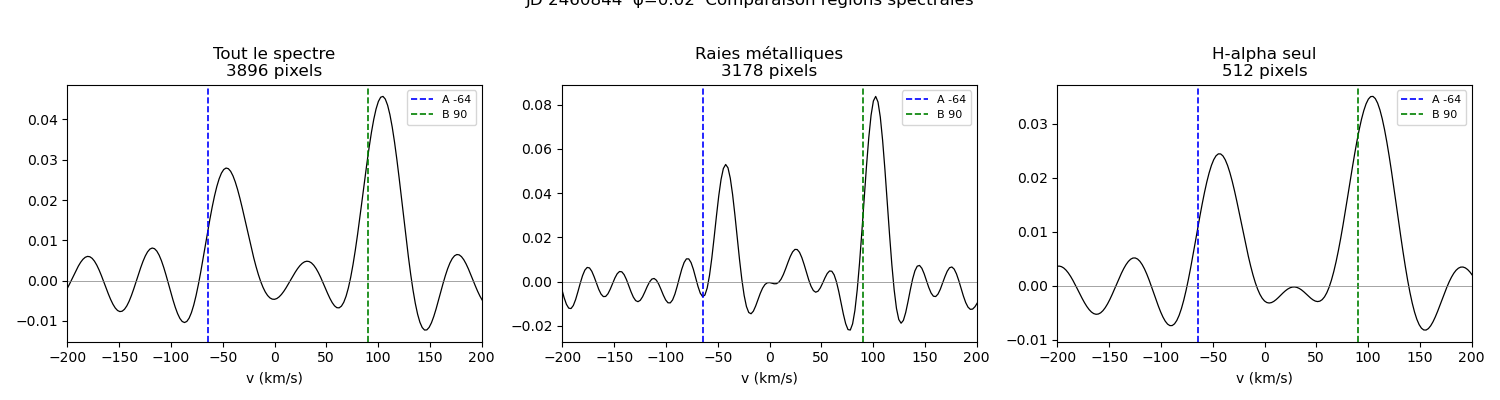

In [65]:
# Test : BF sur H-alpha seul vs BF sur les raies métalliques seules
# Sur un spectre bien séparé (JD 2460844, φ=0.02)

entry = data_list[1]  # JD 2460844
wave = entry['spec'].wavelength.value
flux_raw = entry['spec'].flux.value
obs_flux = flux_raw / np.percentile(flux_raw, 95) - 1.0

# Région 1 : raies métalliques seules (sans H-alpha)
region_metal  = (wave > 6490) & (wave < 6545) | \
                (wave > 6580) & (wave < 6700)

# Région 2 : H-alpha seul
region_halpha = (wave > 6550) & (wave < 6575)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, region) in zip(axes, [
    ('Tout le spectre',   np.ones(len(wave), dtype=bool)),
    ('Raies métalliques', region_metal),
    ('H-alpha seul',      region_halpha)
]):
    wave_sub = wave[region]
    obs_sub  = obs_flux[region]
    
    # Template sur la même sous-région
    f_interp = interp1d(wave_ref, mask_template, 
                        bounds_error=False, fill_value=0)
    mask_sub = f_interp(wave_sub)
    
    v_axis, bf = compute_broadening_function(obs_sub, mask_sub)
    bf = -bf
    
    v_bary = get_barycentric_correction(entry['jd']).value
    ph = ((entry['jd'] - T0_REF) % P) / P
    vta = rv_kepler(np.array([entry['jd']]), T0_REF, P, 
                    68.2, 0.19, 190, -10.5)[0] - v_bary
    vtb = rv_kepler(np.array([entry['jd']]), T0_REF, P, 
                    70.8, 0.19, 10, -10.5)[0] - v_bary
    
    ax.plot(v_axis, bf, 'k-', lw=0.9)
    ax.axvline(vta, color='blue',  ls='--', lw=1.2, label=f'A {vta:.0f}')
    ax.axvline(vtb, color='green', ls='--', lw=1.2, label=f'B {vtb:.0f}')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-200, 200)
    ax.set_title(f'{label}\n{len(wave_sub)} pixels')
    ax.legend(fontsize=8)
    ax.set_xlabel('v (km/s)')

plt.suptitle(f'JD 2460844  φ={ph:.2f}  Comparaison régions spectrales', y=1.02)
plt.tight_layout()
plt.savefig('images/bf_regions.png', dpi=120)
plt.show()

In [67]:
# Bilan complet des décalages sur JD 2460844 (φ=0.02, bien séparé)
entry = data_list[1]
jd = entry['jd']

v_bary = get_barycentric_correction(jd).value
print(f"Correction barycentrique        : {v_bary:+.2f} km/s")
print(f"OFFSET_INST actuel              : {OFFSET_INST:+.2f} km/s")

# Position attendue des pics dans le référentiel BF (axe v_axis)
# = VR_orbitale - v_bary  (avant correction barycentrique)
vta_orb = rv_kepler(np.array([jd]), T0_REF, P, 68.2, 0.19, 190,  -10.5)[0]
vtb_orb = rv_kepler(np.array([jd]), T0_REF, P, 70.8, 0.19,  10,  -10.5)[0]
print(f"\nVR orbitale A (pro)             : {vta_orb:+.2f} km/s")
print(f"VR orbitale B (pro)             : {vtb_orb:+.2f} km/s")
print(f"Position pic A dans BF          : {vta_orb - v_bary:+.2f} km/s")
print(f"Position pic B dans BF          : {vtb_orb - v_bary:+.2f} km/s")

# Ce qu'on mesure réellement dans la BF
# (lire visuellement sur le plot JD 2460844)
print(f"\nPosition pic A observée (visuel): ~ -50 km/s (à lire sur plot)")
print(f"Position pic B observée (visuel): ~ +75 km/s (à lire sur plot)")

# Décalage résiduel
print(f"\nDécalage résiduel A : {-50 - (vta_orb - v_bary):+.1f} km/s")
print(f"Décalage résiduel B : {+75 - (vtb_orb - v_bary):+.1f} km/s")

Correction barycentrique        : -21.93 km/s
OFFSET_INST actuel              : -6.00 km/s

VR orbitale A (pro)             : -85.99 km/s
VR orbitale B (pro)             : +67.87 km/s
Position pic A dans BF          : -64.06 km/s
Position pic B dans BF          : +89.80 km/s

Position pic A observée (visuel): ~ -50 km/s (à lire sur plot)
Position pic B observée (visuel): ~ +75 km/s (à lire sur plot)

Décalage résiduel A : +14.1 km/s
Décalage résiduel B : -14.8 km/s


In [68]:
# Après la dernière itération, affiche les points B avec leur phase
# et compare à ce qu'on attend physiquement
jd_arr_full = np.array(jd_list)
vr_B_full   = np.array(results_B)
phases_full = np.array(phases)

print("Points B mesurés :")
print(f"{'φ':<8} {'VR_B':>10} {'VR_B_attendu':>14} {'écart':>8}")
print("-" * 45)
for ph, vr, jd in zip(phases_full, vr_B_full, jd_arr_full):
    if np.isfinite(vr):
        # VR attendue avec solution pro
        vr_exp = rv_kepler(np.array([jd]), T0_REF, P, 70.8, 0.19, 10, -10.5)[0]
        print(f"{ph:.3f}  {vr:>10.2f}  {vr_exp:>14.2f}  {vr-vr_exp:>8.2f}")

Points B mesurés :
φ              VR_B   VR_B_attendu    écart
---------------------------------------------
0.924       63.24           64.04     -0.80
0.024       74.57           67.87      6.71
0.125       50.04           23.06     26.99
0.230        1.99          -26.47     28.46
0.334      -80.75          -56.47    -24.27
0.438      -32.97          -67.71     34.73
0.544      -49.85          -63.38     13.53
0.646      -58.76          -44.88    -13.88
0.960       71.19           72.13     -0.94
0.066       62.30           53.00      9.30


  A : 13 points utilisés sur 13
ÉTAPE 1 — Fit orbital sur A
  t0    = 2460841.9878 JD
  K_A   = 60.83 ± 7.43 km/s
  e     = 0.050 ± 0.130
  ω_A   = 110.0 ± 132.0 °
  γ     = -5.79 ± 5.33 km/s
  O-C rms = 13.91 km/s

ÉTAPE 2 — Fit K_B sur 10 points
  Paramètres fixés : t0=2460841.9878  e=0.050  ω_A=110.0°  ω_B=290.0°  γ=-5.79

  Vérification pré-fit (K_B=70 km/s) :
  φ          VR_B obs   VR_B mod      O-C
  ----------------------------------------
  0.154       67.24       64.44      2.80
  0.255       80.64       57.49     23.16
  0.356       66.95       27.72     39.23
  0.668      -27.92      -72.43     44.51
  0.774      -47.02      -69.00     21.98
  0.877      -61.29      -37.95    -23.34
  0.190       76.26       65.24     11.02
  0.296       79.11       47.33     31.78
  0.397       50.21       11.90     38.31
  0.503        8.80      -29.58     38.38

  K_B   = 73.98 ± 13.22 km/s
  O-C rms = 30.12 km/s

SOLUTION ORBITALE FINALE (chemin 2)
Période fixée    P   = 9.5910 j
T0 pér

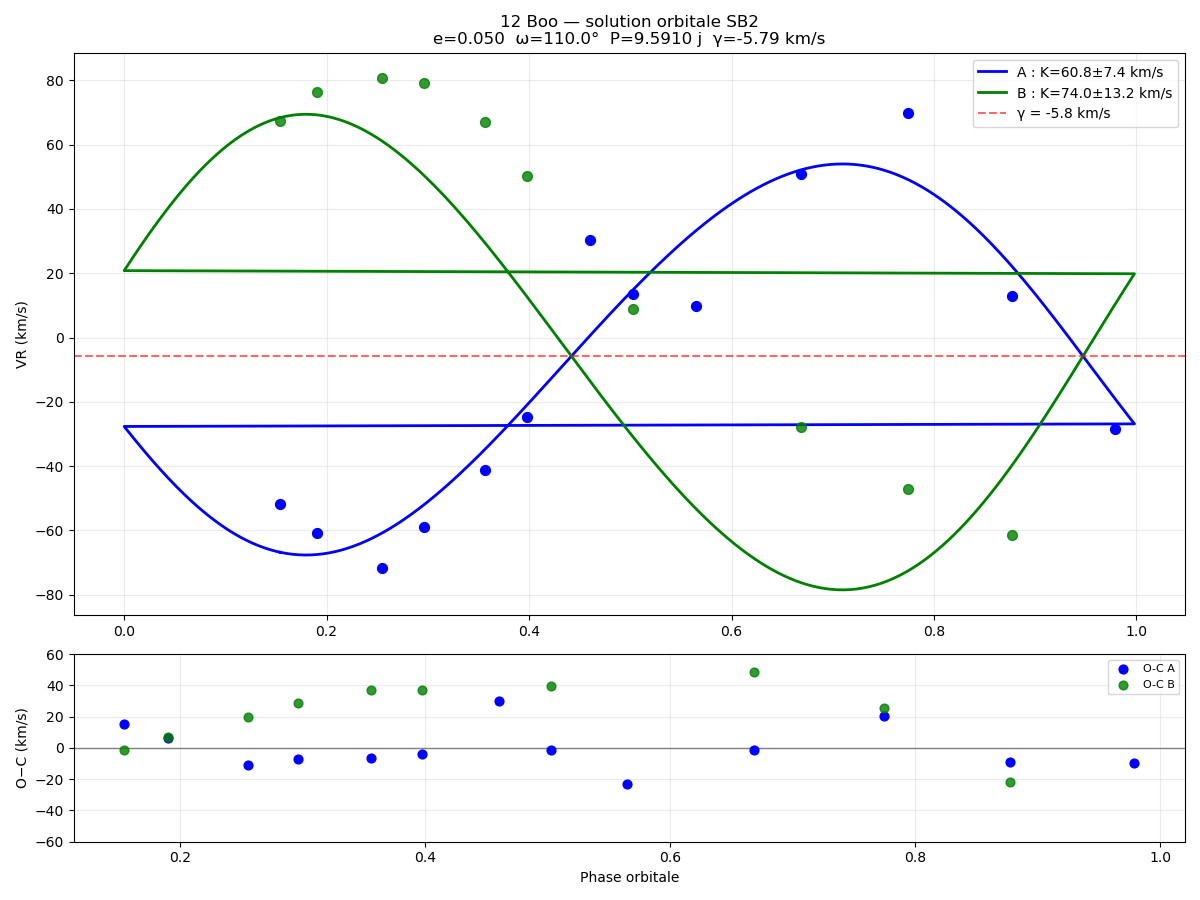

In [69]:
# ============================================================
# CHEMIN 2 : fit séquentiel A → B
# ============================================================

# --- ÉTAPE 1 : fit A seul (tous paramètres libres) ---

popt_A, perr_A = fit_rv_curve(jd_arr, vr_A, P_fixed=P, is_star_b=False)
t0_fit, K_A_fit, e_fit, omega_A_fit, gamma_fit = popt_A

print("ÉTAPE 1 — Fit orbital sur A")
print(f"  t0    = {t0_fit:.4f} JD")
print(f"  K_A   = {K_A_fit:.2f} ± {perr_A[1]:.2f} km/s")
print(f"  e     = {e_fit:.3f} ± {perr_A[2]:.3f}")
print(f"  ω_A   = {omega_A_fit:.1f} ± {perr_A[3]:.1f} °")
print(f"  γ     = {gamma_fit:.2f} ± {perr_A[4]:.2f} km/s")

# Résidu O-C sur A
vr_A_model = rv_kepler(jd_arr, t0_fit, P, K_A_fit, e_fit, omega_A_fit, gamma_fit)
oc_A = vr_A[np.isfinite(vr_A)] - vr_A_model[np.isfinite(vr_A)]
print(f"  O-C rms = {np.sqrt(np.mean(oc_A**2)):.2f} km/s")

# --- ÉTAPE 2 : fit K_B seul, tout le reste fixé depuis A ---

def fit_kb_only(jd_arr, vr_B, t0, P_fixed, e, omega_A, gamma):
    """
    Ajuste K_B uniquement.
    Tous les paramètres orbitaux sont fixés depuis le fit A.
    omega_B = omega_A + 180° imposé.
    """
    jd_arr = np.array(jd_arr, dtype=float)
    vr_B   = np.array(vr_B,   dtype=float)
    good   = np.isfinite(vr_B)
    jd_fit = jd_arr[good]
    vr_fit = vr_B[good]
    
    print(f"\nÉTAPE 2 — Fit K_B sur {good.sum()} points")
    print(f"  Paramètres fixés : t0={t0:.4f}  e={e:.3f}  "
          f"ω_A={omega_A:.1f}°  ω_B={omega_A+180:.1f}°  γ={gamma:.2f}")
    
    # Affiche les résidus attendus avec K_B=70 pour vérification visuelle
    vr_B_pred_70 = rv_kepler(jd_fit, t0, P_fixed, 70.0, e, omega_A+180, gamma)
    print(f"\n  Vérification pré-fit (K_B=70 km/s) :")
    print(f"  {'φ':<8} {'VR_B obs':>10} {'VR_B mod':>10} {'O-C':>8}")
    print(f"  {'-'*40}")
    ph_fit = ((jd_fit - t0) % P_fixed) / P_fixed
    for ph, vo, vm in zip(ph_fit, vr_fit, vr_B_pred_70):
        print(f"  {ph:.3f}  {vo:>10.2f}  {vm:>10.2f}  {vo-vm:>8.2f}")
    
    def model(t, K_B):
        return rv_kepler(t, t0, P_fixed, K_B, e, omega_A + 180, gamma)
    
    popt, pcov = curve_fit(
        model, jd_fit, vr_fit,
        p0=[70.0],
        bounds=([30.0], [120.0]),
        max_nfev=10000
    )
    K_B_fit = popt[0]
    K_B_err = np.sqrt(pcov[0, 0])
    
    # Résidu O-C sur B
    vr_B_model = rv_kepler(jd_fit, t0, P_fixed, K_B_fit, e, omega_A+180, gamma)
    oc_B = vr_fit - vr_B_model
    rms_B = np.sqrt(np.mean(oc_B**2))
    
    print(f"\n  K_B   = {K_B_fit:.2f} ± {K_B_err:.2f} km/s")
    print(f"  O-C rms = {rms_B:.2f} km/s")
    
    return K_B_fit, K_B_err

K_B_fit, K_B_err = fit_kb_only(
    jd_arr, vr_B,
    t0=t0_fit, P_fixed=P,
    e=e_fit, omega_A=omega_A_fit, gamma=gamma_fit
)

# --- ÉTAPE 3 : résultats finaux + graphique ---

ma, mb = calculate_masses(K_A_fit, K_B_fit, P, e_fit)

print("\n" + "=" * 45)
print("SOLUTION ORBITALE FINALE (chemin 2)")
print("=" * 45)
print(f"Période fixée    P   = {P:.4f} j")
print(f"T0 périastre     t0  = {t0_fit:.4f} JD")
print(f"Excentricité     e   = {e_fit:.3f} ± {perr_A[2]:.3f}")
print(f"Arg. périastre   ω_A = {omega_A_fit:.1f} ± {perr_A[3]:.1f} °")
print(f"                 ω_B = {omega_A_fit+180:.1f} °  (imposé)")
print(f"Vit. systémique  γ   = {gamma_fit:.2f} ± {perr_A[4]:.2f} km/s")
print(f"Demi-amplitude   K_A = {K_A_fit:.2f} ± {perr_A[1]:.2f} km/s")
print(f"Demi-amplitude   K_B = {K_B_fit:.2f} ± {K_B_err:.2f} km/s")
print("-" * 45)
print(f"M_A sin³i = {ma:.3f} M☉")
print(f"M_B sin³i = {mb:.3f} M☉")
print("=" * 45)

# Graphique final
t_plot  = np.linspace(jd_arr.min(), jd_arr.min() + P, 500)
ph_plot = ((t_plot - t0_fit) % P) / P

vA_plot = rv_kepler(t_plot, t0_fit, P, K_A_fit, e_fit, omega_A_fit,       gamma_fit)
vB_plot = rv_kepler(t_plot, t0_fit, P, K_B_fit, e_fit, omega_A_fit + 180, gamma_fit)

good_A = np.isfinite(vr_A)
good_B = np.isfinite(vr_B)
ph_obs = ((jd_arr - t0_fit) % P) / P

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), 
                                 gridspec_kw={'height_ratios': [3, 1]})

# Courbe principale
ax1.plot(ph_plot, vA_plot, 'b-', lw=2,
         label=f'A : K={K_A_fit:.1f}±{perr_A[1]:.1f} km/s')
ax1.plot(ph_plot, vB_plot, 'g-', lw=2,
         label=f'B : K={K_B_fit:.1f}±{K_B_err:.1f} km/s')
ax1.axhline(gamma_fit, color='red', ls='--', alpha=0.6,
            label=f'γ = {gamma_fit:.1f} km/s')
ax1.scatter(ph_obs[good_A], vr_A[good_A], 
            color='blue', s=50, zorder=3)
ax1.scatter(ph_obs[good_B], vr_B[good_B], 
            color='green', s=50, zorder=3, alpha=0.8)
ax1.set_ylabel('VR (km/s)')
ax1.set_title(f'12 Boo — solution orbitale SB2\n'
              f'e={e_fit:.3f}  ω={omega_A_fit:.1f}°  '
              f'P={P:.4f} j  γ={gamma_fit:.2f} km/s')
ax1.legend()
ax1.grid(alpha=0.25)

# Résidus O-C
vr_A_mod = rv_kepler(jd_arr, t0_fit, P, K_A_fit, e_fit, omega_A_fit, gamma_fit)
vr_B_mod = rv_kepler(jd_arr, t0_fit, P, K_B_fit, e_fit, omega_A_fit+180, gamma_fit)
oc_A_all = vr_A - vr_A_mod
oc_B_all = vr_B - vr_B_mod

ax2.axhline(0, color='gray', lw=1)
ax2.scatter(ph_obs[good_A], oc_A_all[good_A], 
            color='blue', s=40, zorder=3, label='O-C A')
ax2.scatter(ph_obs[good_B], oc_B_all[good_B], 
            color='green', s=40, zorder=3, alpha=0.8, label='O-C B')
ax2.set_ylabel('O−C (km/s)')
ax2.set_xlabel('Phase orbitale')
ax2.set_ylim(-60, 60)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('images/solution_orbitale_finale.png', dpi=150)
plt.show()